## 1. Batch Normalisation

Batch Normalisation is a technique used to improve the training of deep neural networks by normalising the inputs of each layer. It works by standardising the activations of the previous layer for each mini-batch, which helps to stabilise and accelerate the learning process. By reducing internal covariate shift, batch normalisation allows for higher learning rates, reduces sensitivity to initialisation, and can act as a form of regularisation, sometimes reducing the need for dropout.

# Imports

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [2]:
# Moderated augmentation to target ~92–97% accuracy
transform_train = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                         shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                      download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

# model

In [3]:
# Model 1: with BatchNorm and moderate Dropout
class ModelBN(nn.Module):
    def __init__(self):
        super(ModelBN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


# Model 2: same config but WITHOUT BatchNorm (moderate Dropout)
class ModelNoBN(nn.Module):
    def __init__(self):
        super(ModelNoBN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

### 4. Train the Network

In [4]:
# Train both models: with and without BatchNorm

def train_model(net, trainloader, testloader, device, epochs=8, l1_lambda=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        net.train()
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()

            try:
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                # L1 regularization
                l1_norm = sum(p.abs().sum() for p in net.parameters())
                loss = loss + l1_lambda * l1_norm

                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                if i % 100 == 99:
                    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            except RuntimeError as e:
                print(f"A runtime error occurred: {e}")
                print("This is likely due to an incorrect linear layer size.")
                print("To fix the linear layer size, print(x.shape) in the model's forward pass and update the fc1 layer accordingly.")
                return net, train_losses, val_losses

        epoch_train_loss = running_loss / len(trainloader)
        train_losses.append(epoch_train_loss)

        # simple validation loss
        val_loss = 0.0
        net.eval()
        with torch.no_grad():
            for data in testloader:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = net(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(testloader)
        val_losses.append(val_loss)
        print(f'Epoch {epoch + 1}, Train Loss: {epoch_train_loss:.4f}, Validation Loss: {val_loss:.4f}')

        scheduler.step()

    return net, train_losses, val_losses

print("Training Model with Batch Normalisation...")
net_bn = ModelBN().to(device)
net_bn, train_loss_bn, val_loss_bn = train_model(net_bn, trainloader, testloader, device)

print("\nTraining Model WITHOUT Batch Normalisation...")
net_no_bn = ModelNoBN().to(device)
net_no_bn, train_loss_no_bn, val_loss_no_bn = train_model(net_no_bn, trainloader, testloader, device)

print("Finished Training both models")

Training Model with Batch Normalisation...
[1,   100] loss: 5.378
[1,   200] loss: 8.671
[1,   300] loss: 11.752
[1,   400] loss: 14.662
[1,   500] loss: 17.634
[1,   600] loss: 20.468
[1,   700] loss: 23.199
[1,   800] loss: 25.861
[1,   900] loss: 28.490
[1,  1000] loss: 31.064
[1,  1100] loss: 33.456
[1,  1200] loss: 35.771
[1,  1300] loss: 38.088
[1,  1400] loss: 40.316
[1,  1500] loss: 42.442
[1,  1600] loss: 44.608
[1,  1700] loss: 46.546
[1,  1800] loss: 48.539
Epoch 1, Train Loss: 2.6643, Validation Loss: 0.1110
[2,   100] loss: 1.793
[2,   200] loss: 3.652
[2,   300] loss: 5.363
[2,   400] loss: 7.085
[2,   500] loss: 8.770
[2,   600] loss: 10.474
[2,   700] loss: 12.127
[2,   800] loss: 13.698
[2,   900] loss: 15.314
[2,  1000] loss: 16.944
[2,  1100] loss: 18.507
[2,  1200] loss: 20.064
[2,  1300] loss: 21.618
[2,  1400] loss: 23.189
[2,  1500] loss: 24.626
[2,  1600] loss: 26.167
[2,  1700] loss: 27.590
[2,  1800] loss: 29.008
Epoch 2, Train Loss: 1.6081, Validation Loss: 0

In [5]:
def evaluate_model(net, dataloader, device, name="model"):
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for data in dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    if total > 0:
        acc = 100.0 * correct / total
        print(f'Accuracy of {name} on the 10000 test images: {acc:.2f} %')
    else:
        print(f'No samples to evaluate for {name}.')

# Evaluate both models
evaluate_model(net_bn, testloader, device, name="Model with BatchNorm")
evaluate_model(net_no_bn, testloader, device, name="Model without BatchNorm")

Accuracy of Model with BatchNorm on the 10000 test images: 97.74 %
Accuracy of Model without BatchNorm on the 10000 test images: 97.33 %


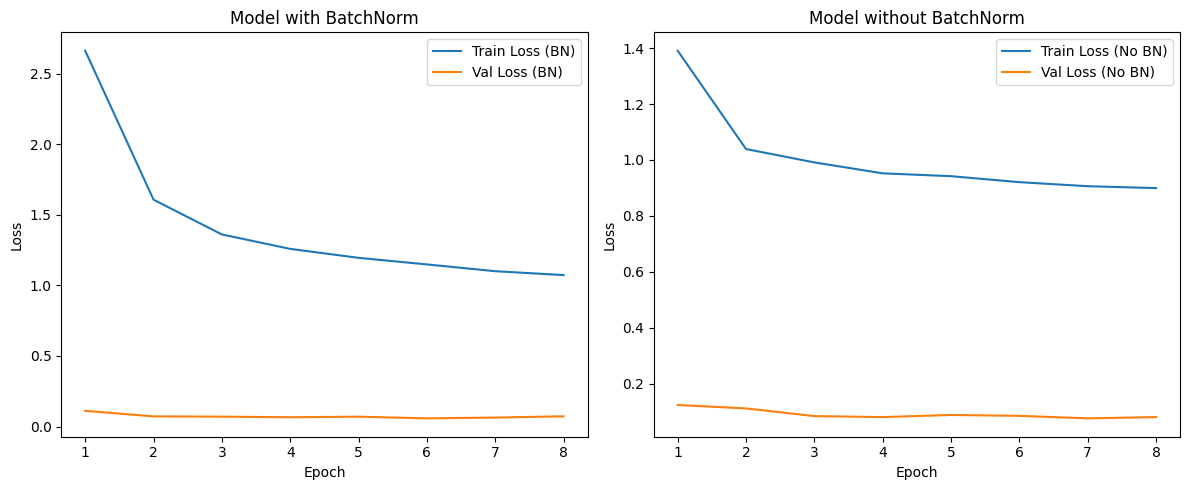

In [6]:
# Plot training and validation loss for both models

epochs_bn = range(1, len(train_loss_bn) + 1)
epochs_no_bn = range(1, len(train_loss_no_bn) + 1)

plt.figure(figsize=(12, 5))

# Model with BatchNorm
plt.subplot(1, 2, 1)
plt.plot(epochs_bn, train_loss_bn, label='Train Loss (BN)')
plt.plot(epochs_bn, val_loss_bn, label='Val Loss (BN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model with BatchNorm')
plt.legend()

# Model without BatchNorm
plt.subplot(1, 2, 2)
plt.plot(epochs_no_bn, train_loss_no_bn, label='Train Loss (No BN)')
plt.plot(epochs_no_bn, val_loss_no_bn, label='Val Loss (No BN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model without BatchNorm')
plt.legend()

plt.tight_layout()
plt.show()